# Import

In [ ]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import (
    mobilenet_v3_large
)
import os
import numpy as np

# final image shape (W, H)
image_shape = (256, 128)

DATASET_PATH = os.path.join(os.getcwd(), "Dataset", "Dataset", "Dataset")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


# Data preprocessing

In [ ]:
# -----------------------------
# 1) Class palette (GT colors)
# -----------------------------
CLASS_COLORS = [
    (0,   0,   0),     # class 0
    (0,  60,   0),     # class 1
    (0, 255,   0),     # class 2
    (102,102,  51),    # class 3
    (170,170, 170),    # class 4
    (0, 120, 255),     # class 5
]
NUM_CLASSES = len(CLASS_COLORS)
IGNORE = 255

COLOR_TO_ID = {c: i for i, c in enumerate(CLASS_COLORS)}
ID_TO_COLOR = np.array(CLASS_COLORS, dtype=np.uint8)  # (6,3)

# ---------------------------------------
# 2) Load images (RGB, depth_color, GT)
# ---------------------------------------
def load_the_image(path, image_shape):
    """Load RGB, depth_color, and GT_color images into numpy arrays."""
    
    ### Your Code Here ####
    rgb_list, depth_list, gt_color_list = [], [], []
    lists = depth_list, gt_color_list, rgb_list #used to append images to the correct list in the upcoming for-loop
    for i, el in enumerate(os.listdir(path)[:3]): #ignore train.txt and valid.txt
        for img in os.listdir(f'{path}/{el}'):
            image = cv.imread(f'{path}/{el}/{img}')
            image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
            image = cv.resize(image, image_shape)
            lists[i].append(image)
            
    #######################
    return np.array(rgb_list), np.array(depth_list), np.array(gt_color_list)

# ---------------------------------------
# 3) Convert GT RGB colors -> class IDs
# ---------------------------------------
def remap_mask_rgb_to_ids(mask_rgb):
    """
    mask_rgb: (H,W,3) uint8 with colors from CLASS_COLORS
    returns: (H,W) uint8 with values 0..5, and 255 for unknown
    """
    
    ### Your Code Here ####
    out = np.full((mask_rgb.shape[:2]), fill_value=IGNORE)
    for class_id, color in enumerate(CLASS_COLORS):
        color_match = np.all(mask_rgb == color, axis=-1)
        out[color_match] = class_id
        
    #######################
    return out

# ---------------------------------------
# 4) Convert predicted IDs -> GT colors
# ---------------------------------------
def ids_to_color(mask_ids):
    """
    mask_ids: (H,W) int/uint
    returns: (H,W,3) uint8 colored with CLASS_COLORS; ignore=255 -> black
    """
    
    ### Your Code Here ####
    h, w = mask_ids.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)
    for i in range(len(CLASS_COLORS)):
        colored[mask_ids == i] = CLASS_COLORS[i]
    #######################
    return colored

def convert_prediction_from_logits_helper(logits_chw):
    """
    logits_chw: numpy array (C,H,W)
    returns: (H,W,3) uint8 in the SAME palette as GT_color
    """
    
    ### Your Code Here ####
    pred_ids = np.argmax(logits_chw, axis=0)
    #######################
    return ids_to_color(pred_ids)

# ---------------------------------------
# 5) Load dataset + build integer masks
# ---------------------------------------
train_rgb, train_depth, train_labels_color = load_the_image(f"{DATASET_PATH}/train", image_shape)
valid_rgb, valid_depth, valid_labels_color = load_the_image(f"{DATASET_PATH}/valid", image_shape)
test_rgb,  test_depth,  test_labels_color  = load_the_image(f"{DATASET_PATH}/test",  image_shape)

train_labels = np.stack([remap_mask_rgb_to_ids(m) for m in train_labels_color], axis=0)
valid_labels = np.stack([remap_mask_rgb_to_ids(m) for m in valid_labels_color], axis=0)
test_labels  = np.stack([remap_mask_rgb_to_ids(m) for m in test_labels_color],  axis=0)

# plot input

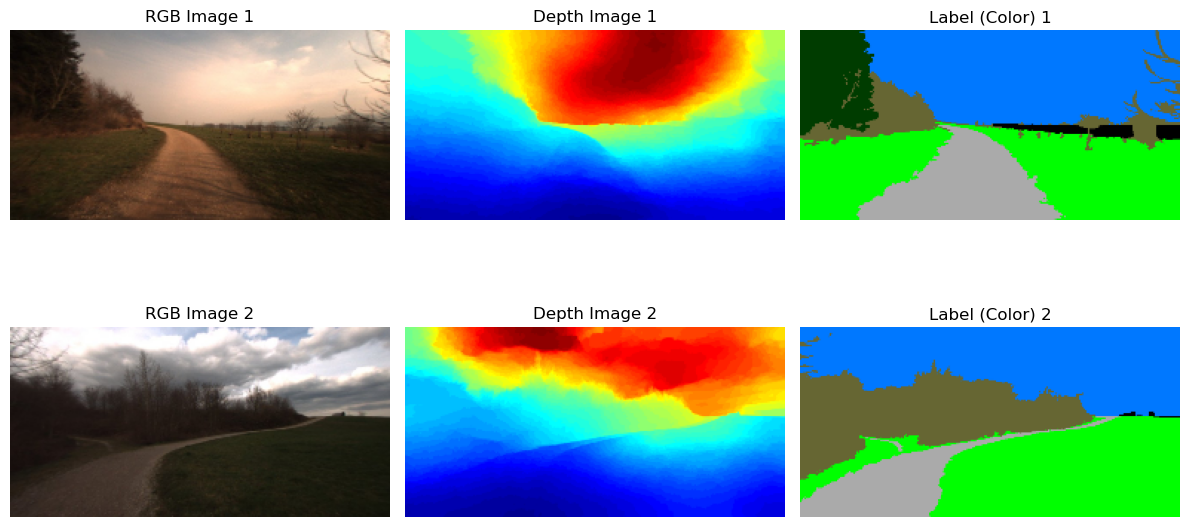

In [3]:
def plot_samples(train_rgb, train_depth, train_labels_color, n=2):
    plt.figure(figsize=(12, 15))
    for i in range(n):
        # ---- Row: RGB | Depth | GT | Pred ----
        ax = plt.subplot(5, 3, (i*3)+1)
        ax.imshow(train_rgb[i].astype(np.uint8))
        ax.set_title(f"RGB Image {i+1}")
        ax.axis("off")

        ax = plt.subplot(5, 3, (i*3)+2)
        ax.imshow(train_depth[i].astype(np.uint8))
        ax.set_title(f"Depth Image {i+1}")
        ax.axis("off")

        ax = plt.subplot(5, 3, (i*3)+3)
        ax.imshow(train_labels_color[i].astype(np.uint8))
        ax.set_title(f"Label (Color) {i+1}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(train_rgb, train_depth, train_labels_color, n=2)

# Make Dataloader

In [4]:
class DualStreamArrayDataset(Dataset):
    def __init__(self, rgb_np, nir_np, mask_np):
        self.rgb = rgb_np
        self.nir = nir_np
        self.mask = mask_np

        ### Your Code Here ####
    def __len__(self):
        return len(self.rgb)

    def __getitem__(self, idx):
        rgb = self.rgb[idx]
        nir = self.nir[idx]
        mask = self.mask[idx]
        #added these after problems in model inference due to data format mismatch
        rgb = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255
        nir = torch.from_numpy(nir).permute(2, 0, 1).float() / 255

        #######################
        return rgb, nir, mask


batch_size = 4

train_loader = DataLoader(DualStreamArrayDataset(train_rgb, train_depth, train_labels),
                          batch_size=batch_size, shuffle=True, num_workers=0)

valid_loader = DataLoader(DualStreamArrayDataset(valid_rgb, valid_depth, valid_labels),
                          batch_size=batch_size, shuffle=False, num_workers=0)

test_loader = DataLoader(DualStreamArrayDataset(test_rgb, test_depth, test_labels),
                         batch_size=batch_size, shuffle=False, num_workers=0)


# Dual Stream Model

In [5]:
class DualStreamSegNet(nn.Module):
    """
    Dual-stream semantic segmentation:
    backbone(rgb) + backbone(nir) -> concat -> head -> upsample to input size
    """

    def __init__(self, list_of_conv_layers, num_classes: int, backbone="MNV3", dropout=0.2):
        super().__init__() 
        ### Your Code Here ####
        
        #backbone
        self.rgb_encoder = mobilenet_v3_large().features
        self.nir_encoder = mobilenet_v3_large().features
        #head
        encoder_out_ch = 960*2 #MNV3 last layer output is 960, multiply by 2 due to concatting
        self.head = self._make_head(in_ch=encoder_out_ch, units=list_of_conv_layers)
        #final conv /classifier
        self.final_classifier = nn.Conv2d(list_of_conv_layers[-1], num_classes, kernel_size=1)
        #upsample to input size
        self.upsample = nn.Upsample(scale_factor=32, mode='bilinear', align_corners=False)
        #######################


    def _make_head(self, in_ch, units, dropout=0.2):
        layers = []
        ch = in_ch
        for u in units:
            layers += [
                nn.Conv2d(ch, u, 3, padding=1, bias=False),
                nn.BatchNorm2d(u),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
            ]
            ch = u
        return nn.Sequential(*layers)

    def forward(self, x_rgb, x_nir):
        ### Your Code Here ####
        feat_rgb = self.rgb_encoder(x_rgb)
        feat_nir = self.nir_encoder(x_nir)
        
        #concat
        cat = torch.cat([feat_rgb, feat_nir], dim=1)
        #head
        x = self.head(cat)
        #final layer & upsample
        logits = self.final_classifier(x)
        logits = self.upsample(logits)
        
        #######################
        return logits

# helper Functions

In [6]:
def pixel_accuracy(logits, mask):
    # logits: (B, C, H, W), mask: (B, H, W)
    ### Your Code Here ####
    preds = torch.argmax(logits, dim=1)
    correct = (preds == mask).sum()
    total = mask.numel()
    return correct / total
    #######################
    
class DiceLoss(nn.Module):
    ### Your Code Here ####
    def __init__(self, num_classes, ignore_index=255):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        mask = (targets != self.ignore_index).unsqueeze(1)
        preds = F.softmax(logits, dim=1) * mask #get predictions, ignore 255
        
        #one-hot encode targets for dice
        #255 is out of bounds for .scatter_, so a slight detour is used here
        tgts_cl = targets
        tgts_cl[targets == 255] = 0
        tgts_onehot = torch.zeros_like(preds)
        tgts_onehot.scatter_(1, tgts_cl.unsqueeze(1), 1)
        
        tgts_onehot = tgts_onehot * mask #again, ignore 255

        #get dims without class for calculations ((B, C, W, H) -> (B, W, H))
        dims = (0, 2, 3)
        intersection = torch.sum(preds * tgts_onehot, dims) #numerator
        union = torch.sum(preds + tgts_onehot, dims) #denominator

        return 1- (2*intersection + 1) / (union + 1) #add 1s to avoid division by 0
    
    #######################
    


# Defince run_epoch and Model Compile

In [7]:
loss_fn = DiceLoss(num_classes=6, ignore_index=255).to(device)

# Build model, loss, optimizer
compiled_model = DualStreamSegNet(
    list_of_conv_layers=[128, 256, 256],
    num_classes=6,
    backbone="MNV3",   # "EFFB2", "RESNET50", "EFFB0", "MNV3"
).to(device)

def freeze_bn(m):
    if isinstance(m, nn.BatchNorm2d):
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)


def run_epoch(model, loader, train=True, max_steps=None):
    if train:
        model.train()
    else:
        model.eval()
    ### Your Code Here ####
    total_loss, total_acc = 0.0, 0.0
    n_batches = 0

    with torch.set_grad_enabled(train): #no_grad on eval
        for i, (x_rgb, x_nir, gt) in enumerate(loader):
            if max_steps != None and i >= max_steps: break
            x_rgb, x_nir, gt =  x_rgb.to(device), x_nir.to(device), gt.to(device)

            #forward & metrics
            logits = model(x_rgb, x_nir)
            loss = loss_fn(logits, gt).mean()
            acc = pixel_accuracy(logits, gt)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_acc += acc.item()
            n_batches += 1
    
    #######################
    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


# Run Model

In [8]:
#train model
def train_model(model, epochs, best_val):
    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, train=True)
        valid_loss, valid_acc = run_epoch(model, valid_loader, train=False)
        print(f'Epoch {epoch+1:02d}/{epochs} | train loss: {train_loss:.4f}, acc: {train_acc:.4f} | val loss: {valid_loss:.4f}, acc: {valid_acc:.4f}')
        if valid_acc > best_val: best_val = valid_acc

    return best_val

dual_best_val = 0.0
dual_best_val = train_model(compiled_model, epochs = 20, best_val = dual_best_val) #i was just too unhappy with the accuracy on 10 epochs
# score the model on the test set
dual_test_loss, dual_test_acc = run_epoch(compiled_model, test_loader, train=False)
print(f'\nTest loss: {dual_test_loss:.4f}\nTest pixel accuracy: {dual_test_acc:.4f}')

Epoch 01/20 | train loss: 0.6610, acc: 0.6106 | val loss: 0.7447, acc: 0.6505
Epoch 02/20 | train loss: 0.5480, acc: 0.7312 | val loss: 0.7391, acc: 0.6458
Epoch 03/20 | train loss: 0.5055, acc: 0.7730 | val loss: 0.7415, acc: 0.6011
Epoch 04/20 | train loss: 0.4832, acc: 0.7875 | val loss: 0.7333, acc: 0.6516
Epoch 05/20 | train loss: 0.4616, acc: 0.8070 | val loss: 0.7424, acc: 0.5497
Epoch 06/20 | train loss: 0.4483, acc: 0.8159 | val loss: 0.7387, acc: 0.6128
Epoch 07/20 | train loss: 0.4265, acc: 0.8277 | val loss: 0.7502, acc: 0.5588
Epoch 08/20 | train loss: 0.4146, acc: 0.8317 | val loss: 0.7324, acc: 0.6031
Epoch 09/20 | train loss: 0.4056, acc: 0.8344 | val loss: 0.7175, acc: 0.6479
Epoch 10/20 | train loss: 0.3919, acc: 0.8413 | val loss: 0.7224, acc: 0.5522
Epoch 11/20 | train loss: 0.3883, acc: 0.8508 | val loss: 0.7241, acc: 0.5573
Epoch 12/20 | train loss: 0.3757, acc: 0.8533 | val loss: 0.6456, acc: 0.7125
Epoch 13/20 | train loss: 0.3704, acc: 0.8584 | val loss: 0.5765

# Show prediction

In [9]:
def convert_prediction_from_logits(logits_chw, number_of_classes, height_of_pred_image=None, width_of_pred_image=None):
    """logits_chw: numpy array (C, H, W). Returns RGB (H, W, 3) with GT colors."""
    
    ### Your Code Here ####
    #here I used an earlier method (with originally the same name), which would've been left without purpose otherwise
    result_holder = convert_prediction_from_logits_helper(logits_chw) 
    #######################
    return result_holder


### Your Code Here ####
def get_predictions(model):
    model.eval()
    with torch.no_grad():
        x_rgb, x_nir, gt = next(iter(test_loader))
        x_rgb, x_nir = x_rgb.to(device), x_nir.to(device)
        logits = model(x_rgb, x_nir)

    predictions = logits.cpu().numpy()
    return predictions

predictions = get_predictions(compiled_model)
#######################

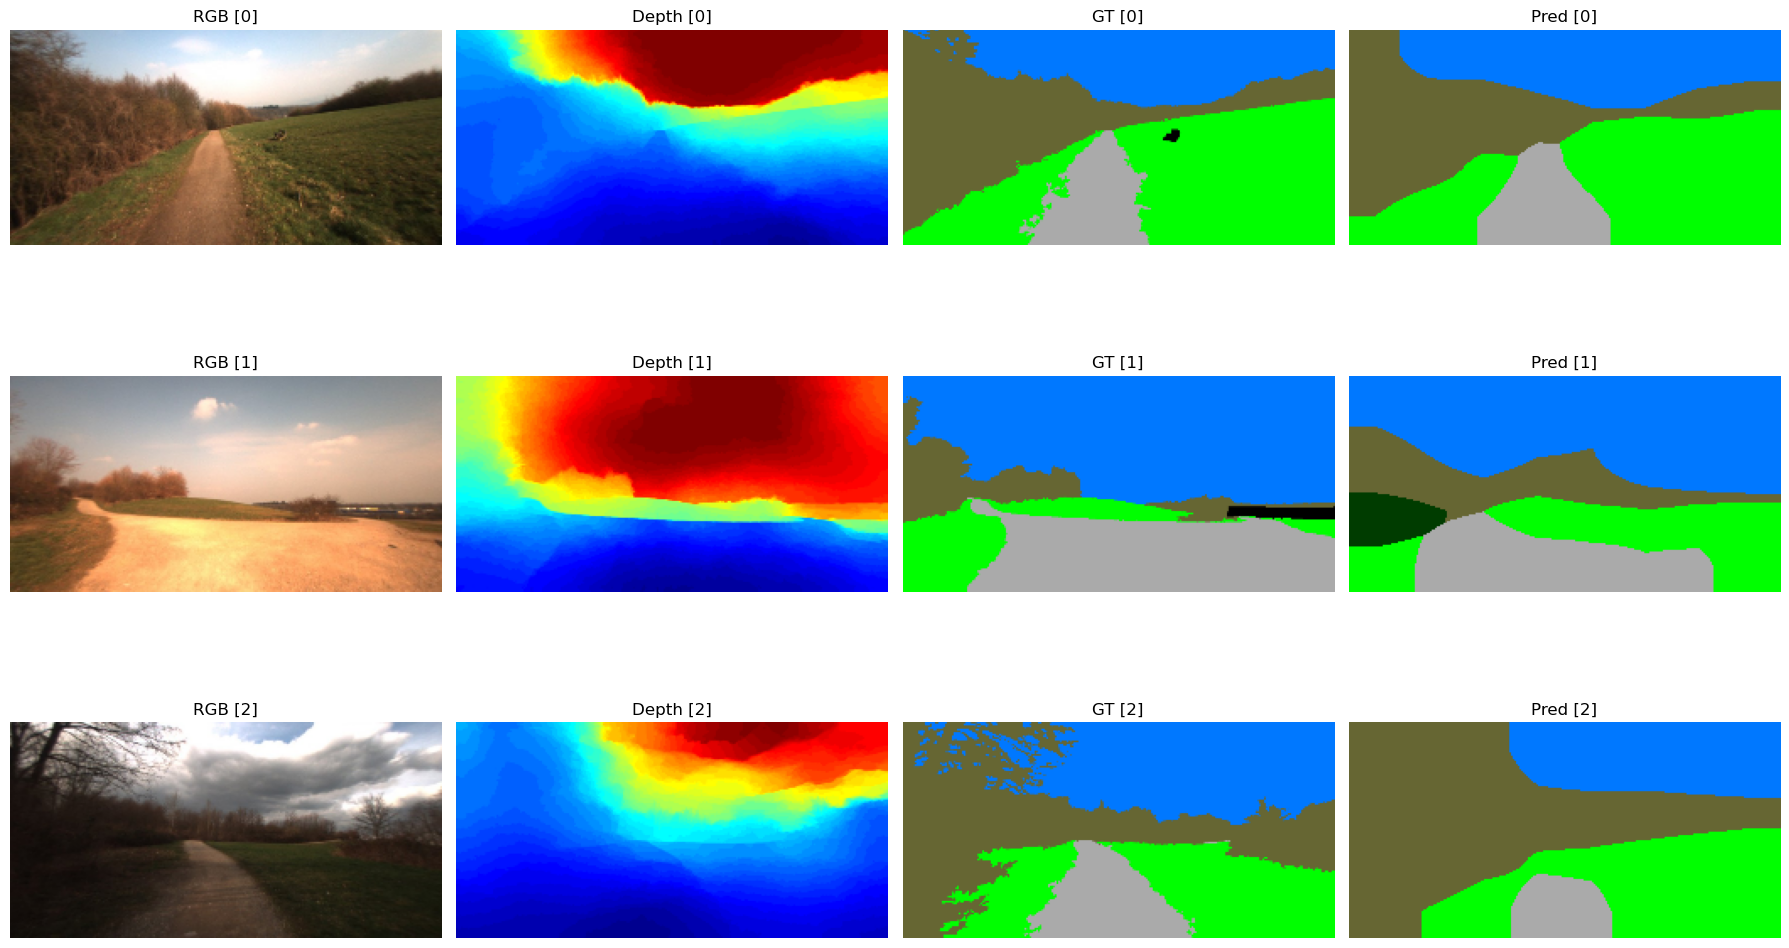

In [10]:
def show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=6, start=0, num_classes=6):
    N = predictions.shape[0]
    idxs = list(range(start, min(start + n, N)))

    plt.figure(figsize=(18, 3.8 * len(idxs)))

    for r, i in enumerate(idxs):
        pred_rgb = convert_prediction_from_logits(predictions[i], number_of_classes=num_classes)  # (H,W,3) RGB

        # ---- Row: RGB | Depth | GT | Pred ----
        ax = plt.subplot(len(idxs), 4, r * 4 + 1)
        ax.imshow(test_rgb[i].astype(np.uint8))
        ax.set_title(f"RGB [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 2)
        ax.imshow(test_depth[i].astype(np.uint8))
        ax.set_title(f"Depth [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 3)
        ax.imshow(test_labels_color[i].astype(np.uint8))
        ax.set_title(f"GT [{i}]")
        ax.axis("off")

        ax = plt.subplot(len(idxs), 4, r * 4 + 4)
        ax.imshow(pred_rgb)
        ax.set_title(f"Pred [{i}]")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage (after you computed `predictions`)
show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=3, start=0, num_classes=6)

# Single Stream

In [11]:
class SingleStreamSegNet(nn.Module):
    """
    Single-stream semantic segmentation:
      backbone(x) -> head -> classifier -> upsample to input size

    Keeps the same forward signature: forward(x_rgb, x_nir)
    so your existing run_epoch(model, loader, ...) still works.
    """
    
    ### Your Code Here ####
    #mostly the same code as in the dual stream model
    def __init__(self, list_of_conv_layers, num_classes: int, stream: str, backbone="MNV3", dropout=0.2):
        super().__init__() 
        self.stream = stream #either rgb or nir, crash otherwise
        #backbone
        self.encoder = mobilenet_v3_large().features
        #head
        encoder_out_ch = 960 #MNV3 last layer output is 960,this time no multiplying
        self.head = self._make_head(in_ch=encoder_out_ch, units=list_of_conv_layers)
        #final conv /classifier
        self.final_classifier = nn.Conv2d(list_of_conv_layers[-1], num_classes, kernel_size=1)
        #upsample to input size
        self.upsample = nn.Upsample(scale_factor=32, mode='bilinear', align_corners=False)

    #reuse
    def _make_head(self, in_ch, units, dropout=0.2):
        layers = []
        ch = in_ch
        for u in units:
            layers += [
                nn.Conv2d(ch, u, 3, padding=1, bias=False),
                nn.BatchNorm2d(u),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=dropout),
            ]
            ch = u
        return nn.Sequential(*layers)

    def forward(self, x_rgb, x_nir):
        if self.stream == "rgb":
            feat = self.encoder(x_rgb)
        if self.stream == "nir":
            feat = self.encoder(x_nir)
        #else crash
        #head
        x = self.head(feat)
        #final layer & upsample
        logits = self.final_classifier(x)
        logits = self.upsample(logits)

        return logits
    
    #######################

In [ ]:
compiled_model = SingleStreamSegNet(
    list_of_conv_layers=[128, 256, 256],
    num_classes=6,
    backbone="MNV3",
    stream="rgb"
).to(device)

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)

tensor(0.)

In [13]:
# Get results on test set
### Your Code Here ####
rgb_best_val = 0.0
rgb_best_val = train_model(compiled_model, epochs = 20, best_val = rgb_best_val) #again go for 20 epochs instead of 10
# score the model on the test set
rgb_test_loss, rgb_test_acc = run_epoch(compiled_model, test_loader, train=False)
print(f'\nTest loss: {rgb_test_loss:.4f}\nTest pixel accuracy: {rgb_test_acc:.4f}')
#######################

Epoch 01/20 | train loss: 0.7102, acc: 0.5187 | val loss: 0.7669, acc: 0.5305
Epoch 02/20 | train loss: 0.5850, acc: 0.6764 | val loss: 0.7628, acc: 0.5455
Epoch 03/20 | train loss: 0.5432, acc: 0.7166 | val loss: 0.7318, acc: 0.6469
Epoch 04/20 | train loss: 0.5141, acc: 0.7451 | val loss: 0.7181, acc: 0.6493
Epoch 05/20 | train loss: 0.4877, acc: 0.7710 | val loss: 0.7270, acc: 0.5735
Epoch 06/20 | train loss: 0.4706, acc: 0.7900 | val loss: 0.7267, acc: 0.5789
Epoch 07/20 | train loss: 0.4559, acc: 0.8009 | val loss: 0.7341, acc: 0.5211
Epoch 08/20 | train loss: 0.4452, acc: 0.8054 | val loss: 0.7443, acc: 0.4523
Epoch 09/20 | train loss: 0.4299, acc: 0.8131 | val loss: 0.7504, acc: 0.4540
Epoch 10/20 | train loss: 0.4090, acc: 0.8262 | val loss: 0.7373, acc: 0.4490
Epoch 11/20 | train loss: 0.4116, acc: 0.8240 | val loss: 0.7172, acc: 0.4702
Epoch 12/20 | train loss: 0.3978, acc: 0.8282 | val loss: 0.6736, acc: 0.5225
Epoch 13/20 | train loss: 0.3892, acc: 0.8393 | val loss: 0.5735

In [14]:
### Your Code Here ####
predictions = get_predictions(compiled_model)
#######################

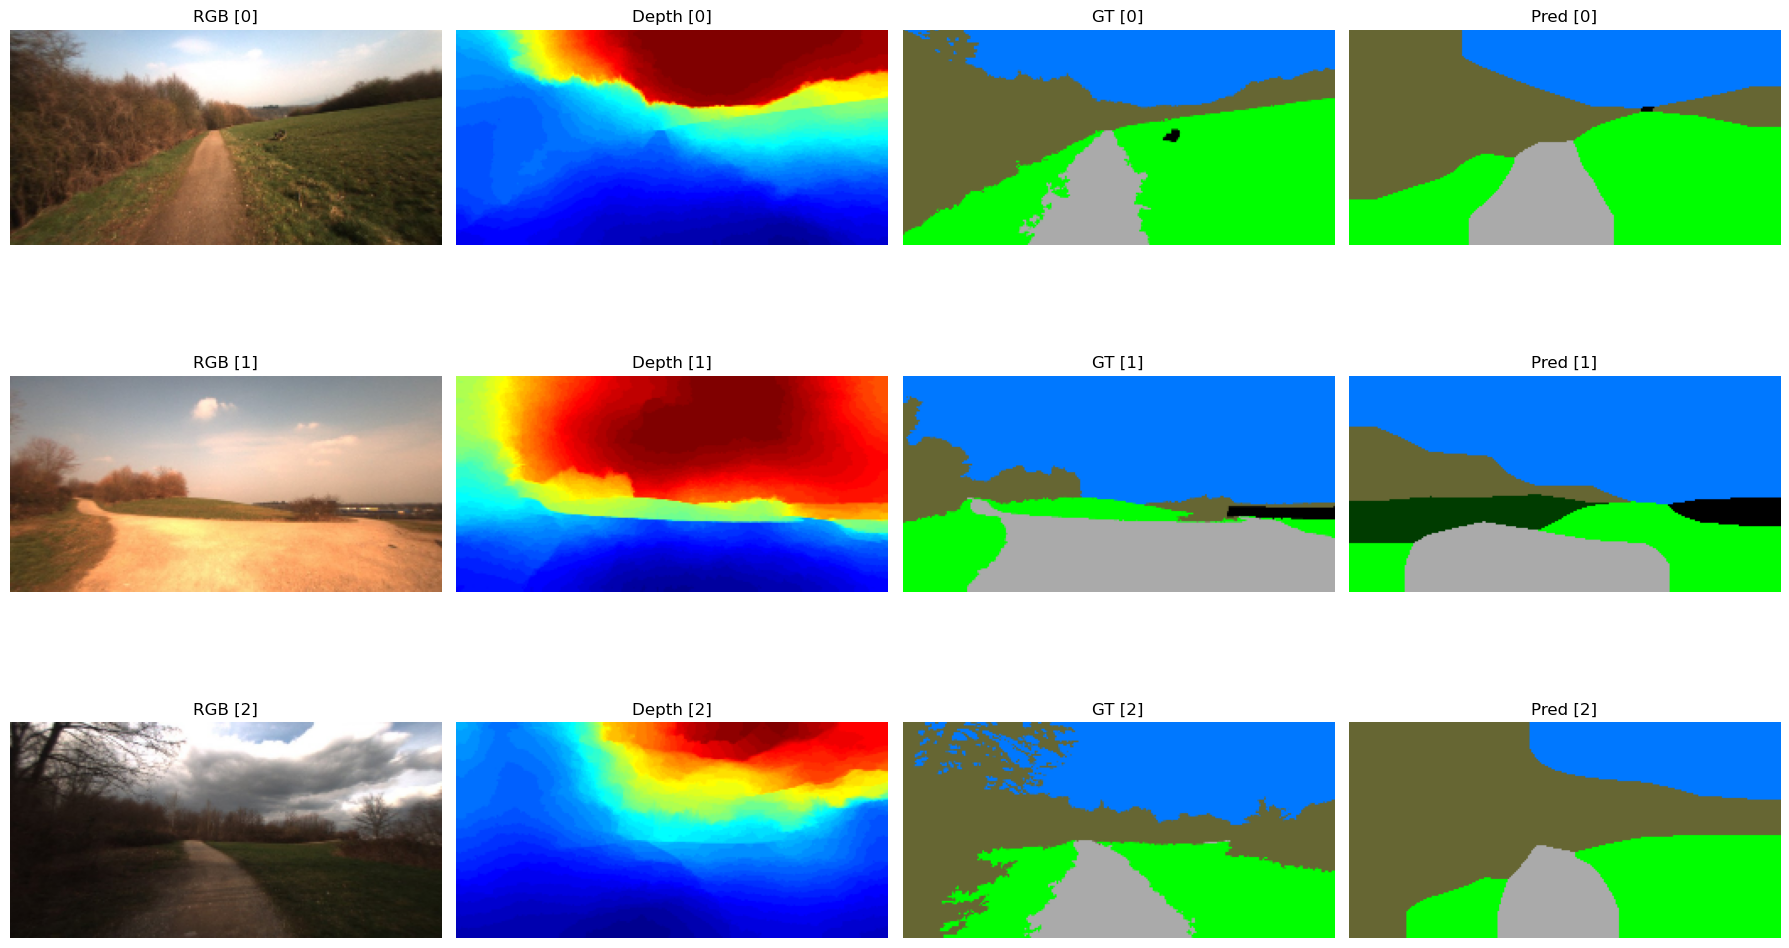

In [15]:
### Your Code Here ####
show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=3, start=0, num_classes=6)
#######################

# Depth Model

In [16]:
#we can use the single stream model here with stream="nir" instead of "rgb" to get depth model
compiled_model = SingleStreamSegNet(
    list_of_conv_layers=[128, 256, 256],
    num_classes=6,
    backbone="MNV3",
    stream="nir"
).to(device)

compiled_model.apply(freeze_bn)
optimizer = torch.optim.AdamW(compiled_model.parameters(), lr=1e-4, weight_decay=1e-4)
torch.nn.utils.clip_grad_norm_(compiled_model.parameters(), 1.0)

tensor(0.)

In [17]:
nir_best_val = 0.0
nir_best_val = train_model(compiled_model, epochs = 20, best_val = nir_best_val) #again go for 20 epochs instead of 10
# score the model on the test set
nir_test_loss, nir_test_acc = run_epoch(compiled_model, test_loader, train=False)
print(f'\nTest loss: {nir_test_loss:.4f}\nTest pixel accuracy: {nir_test_acc:.4f}')

Epoch 01/20 | train loss: 0.6674, acc: 0.6011 | val loss: 0.7888, acc: 0.4929
Epoch 02/20 | train loss: 0.5573, acc: 0.7081 | val loss: 0.7927, acc: 0.4868
Epoch 03/20 | train loss: 0.5200, acc: 0.7478 | val loss: 0.7797, acc: 0.5089
Epoch 04/20 | train loss: 0.4912, acc: 0.7731 | val loss: 0.8035, acc: 0.4787
Epoch 05/20 | train loss: 0.4710, acc: 0.7827 | val loss: 0.7909, acc: 0.4916
Epoch 06/20 | train loss: 0.4553, acc: 0.7996 | val loss: 0.8020, acc: 0.4802
Epoch 07/20 | train loss: 0.4394, acc: 0.8067 | val loss: 0.8031, acc: 0.4806
Epoch 08/20 | train loss: 0.4301, acc: 0.8106 | val loss: 0.8133, acc: 0.4622
Epoch 09/20 | train loss: 0.4144, acc: 0.8235 | val loss: 0.8012, acc: 0.4807
Epoch 10/20 | train loss: 0.4010, acc: 0.8262 | val loss: 0.8357, acc: 0.4305
Epoch 11/20 | train loss: 0.3927, acc: 0.8339 | val loss: 0.8388, acc: 0.4300
Epoch 12/20 | train loss: 0.3847, acc: 0.8437 | val loss: 0.8529, acc: 0.3982
Epoch 13/20 | train loss: 0.3780, acc: 0.8495 | val loss: 0.8324

In [18]:
predictions = get_predictions(compiled_model)

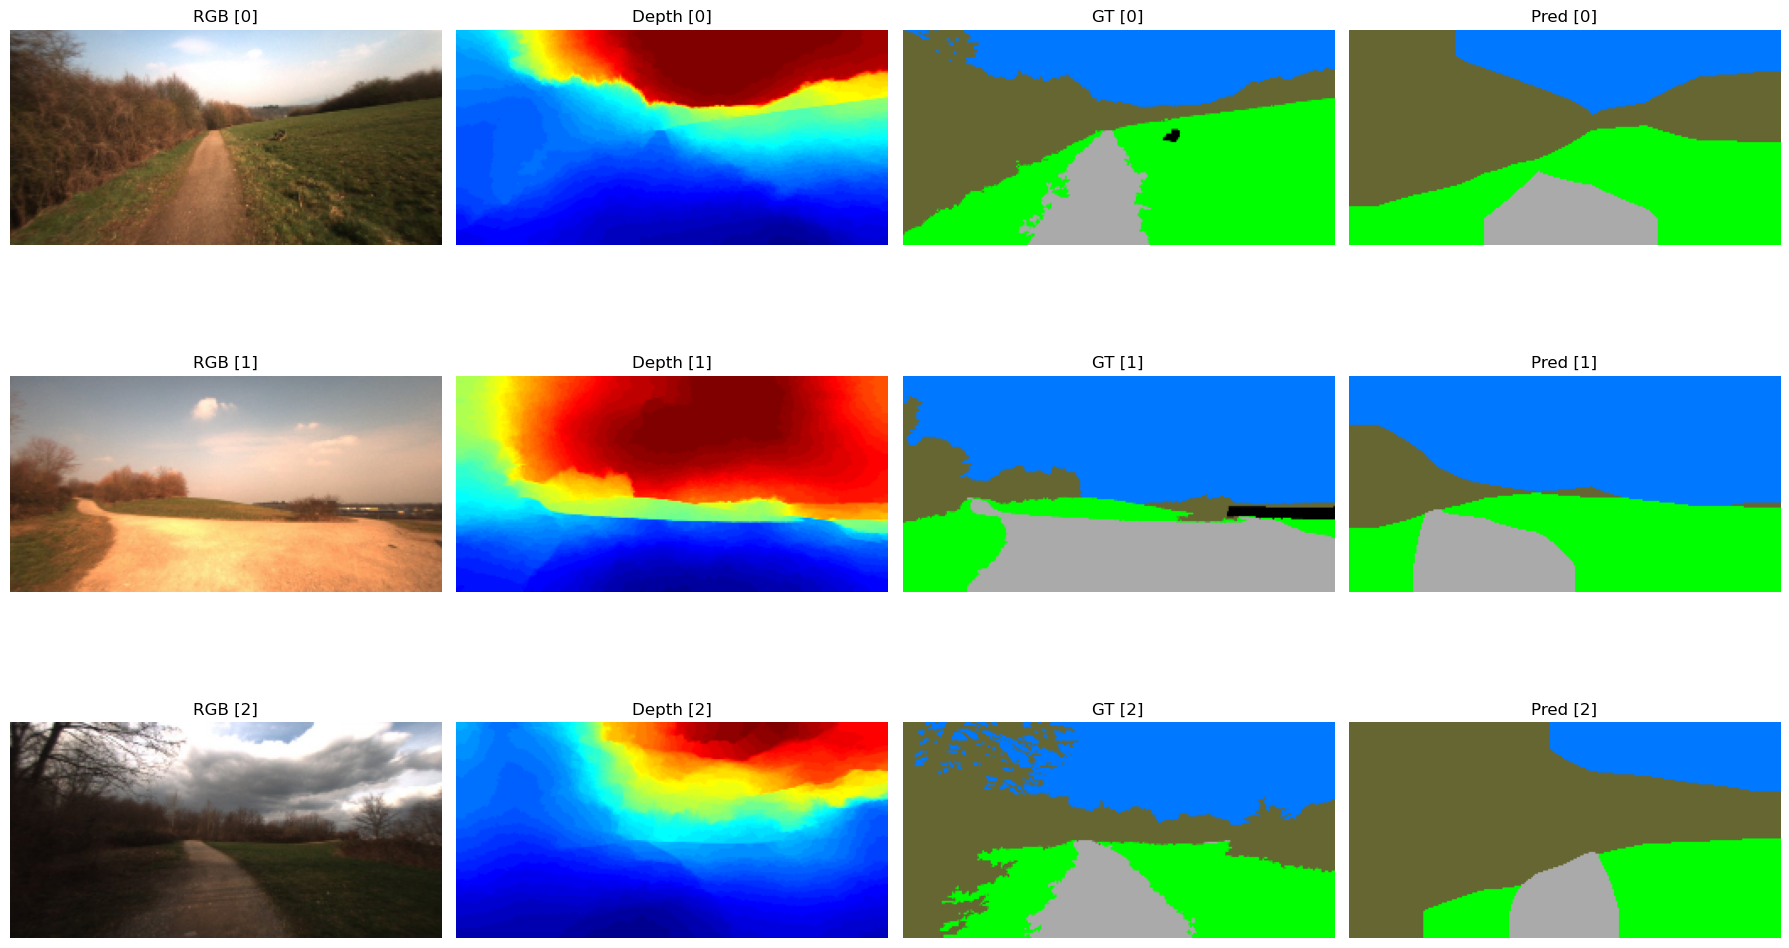

In [19]:
show_comparison_rows(test_rgb, test_depth, test_labels_color, predictions, n=3, start=0, num_classes=6)

# Compare results table

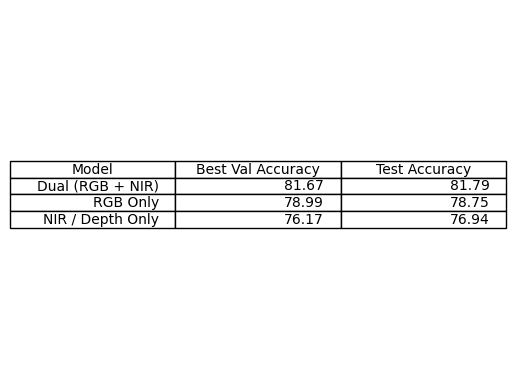

In [20]:
dual_row = 'Dual (RGB + NIR)', round(dual_best_val*100, 2), round(dual_test_acc*100, 2)
rgb_row = 'RGB Only', round(rgb_best_val*100, 2), round(rgb_test_acc*100, 2)
nir_row = 'NIR / Depth Only', round(nir_best_val*100, 2), round(nir_test_acc*100, 2)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=(dual_row, rgb_row, nir_row),
    colLabels=['Model', 'Best Val Accuracy', 'Test Accuracy'],
    loc='center'
)

plt.show()

## Conclusion

### On the results in-general

After running the code for several times, the results on which model performed best fluctuated quite a bit. Most of the time either the dual stream or rgb single stream performed best, but with the comparably small datasets training the models further would be difficult without risking overfitting. However, I decided to leave the results on a run where the dual model performed the best, as it reached the overall highest accuracies between runs of the notebook.

### Dual Stream model

The model was implemented according to the assignment architecture, loading depth and rgb input separately into their own backbones, and concatting the results before passing into the head. The model was trained for 20 epochs on the training set, and reached an accuracy of 81,79 % on the test set, with the best evaluation set accuracy being 81,67 %.

Maybe for results that better fit expectations an additional (or a "fusion dedicated") layer should've been added between the backbone and _make_head() where the model could've gone over the concatted inputs with a smaller kernel instead of reading them straight into the head? This would be my first guess on why the dual model sometimes performed about the same or slightly worse than the rgb only single stream model, although it should perform better on the given task and input.


### Single stream (rgb)

The model was mostly inherited from the dual stream model, with modifications to select which input stream (depth or rgb, in this case rgb) to read into the backbones, and passing them into the head. The model was trained for 20 epochs on the training set, and reached an accuracy of 78,75 % on the test set, with the best evaluation set accuracy being 78,99 %.

The rgb single stream model sometimes slightly outperformed the dual stream model, but would still need improvement. Ideally the depth data would help with some uncertainties as the rgb images in the dataset have many factors such as weather and time of day that effect the quality of the images, but it seems that it sometimes confused the dual stream model or that the it didn't learn from the data properly, and so the rgb single stream model would still sometimes outperform it regardless of the uncertainties in rgb images.


### Single stream (depth/nir)

The model was the same as single stream for rgb, but with stream set to depth/nir instead of rgb. The model was trained for 20 epochs on the training set, and reached an accuracy of 76,94 % on the test set, with the best evaluation set accuracy being 76,17 %.

The single stream depth model performed the worst, which was mostly expected, as the data for it lacks clear differentiation between classes which appear at the same depth level (for example roads and grass would very easily mix up).
